In [7]:
import pandas as pd
import re
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import nltk
import numpy as np


In [46]:
df = pd.read_csv("data/restructured.csv")

In [47]:
df.head()

,roundup_title,topics,story_title,story_text,bias_label
0,"""Dream"" 50 Years Later",Civil Rights,Thousands Gather In D.C. To Mark 1963 Civil Ri...,People are assembling on the National Mall to ...,center
1,"""Dream"" 50 Years Later",Civil Rights,March In Washington To Continue Focus On Civil...,Alice Long planned months ago to use vacation ...,left
2,"""Dream"" 50 Years Later",Civil Rights,Remembering My Uncle's 'Dream',"Fifty years ago, a valiant group of people fro...",right
3,"""Good Shutdown"" in September?",Politics,"President Trump Calls for a ""Good Shutdown"" in...",President Donald Trump made a bold statement o...,right
4,"""Good Shutdown"" in September?",Politics,Trump: US ‘needs a good shutdown’,"President Trump on Tuesday called for a ""good ...",center


### Pre-Process

In [48]:
# Update: keeping useful stopwords and light punctuation, but removing noise like standalone symbols or non-alphabetic tokens
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')
nltk.download('wordnet')

# Helper: map NLTK POS tags to WordNet POS
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

# Improved preprocessing function
def preprocess(text):
    # Lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Tokenize
    tokens = word_tokenize(text)

    # Keep only alphabetic words and useful punctuation (e.g., quotes)
    tokens = [token for token in tokens if token.isalpha() or token in ["'", '"']]

    # POS tagging and lemmatization
    tagged = pos_tag(tokens)
    lemmatizer = WordNetLemmatizer()
    lemmatized = [
        lemmatizer.lemmatize(word, get_wordnet_pos(tag)) for word, tag in tagged
    ]

    return ' '.join(lemmatized)


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Besitzer\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Besitzer\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Besitzer\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Besitzer\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


#### Keep Special Characters for LSTM Text Classification?

Yes — for political bias detection using LSTM or BiLSTM, it's beneficial to **retain punctuation and special characters** like quotes (`'`, `"`) or ellipses (`...`).

##### Why?
- **Framing and tone** often depend on punctuation (e.g., irony, sarcasm).
- **Quotes** can imply indirectness or subjectivity — common in politically charged texts.
- LSTM models can learn **contextual meaning from raw character sequences**.

##### Tip:
Clean only unnecessary noise (e.g., HTML, broken encoding), but **don’t over-sanitize** your text — keep the "flavor" of how things are said.


In [49]:
# combine title and story into one column
df['combined'] = '[TITLE] ' + df['story_title'] + ' [TEXT] ' + df['story_text']


In [50]:
# apply preprocess function on story_title and story_text
df['combined'] = df['combined'].apply(preprocess)

### Check Balance

In [51]:
# check balance of the dataset
df['bias_label'].value_counts()

bias_label
left      8430
right     8375
center    7700
Name: count, dtype: int64

In [52]:
# remove rows where there is no center (group for roundup_title and check if there is a center)

# Count how many bias labels exist per roundup
grouped = df.groupby('roundup_title')['bias_label'].nunique()

# Filter only roundups that contain all 3 labels
valid_titles = grouped[grouped == 3].index

# Keep only rows with those titles
df = df[df['roundup_title'].isin(valid_titles)].copy()


In [53]:
# check balance of the dataset
df['bias_label'].value_counts()

bias_label
center    7564
left      7564
right     7563
Name: count, dtype: int64

### make all the same length by using padding

In [54]:
# splitinto tokens to count the number of tokens
df['token_len'] = df['combined'].apply(lambda x: len(x.split()))
# check the distribution of token lengths
max_len = int(np.percentile(df['token_len'], 95))
print("95th percentile max_len:", max_len)


95th percentile max_len: 109


copy dataset for binary use

In [55]:
df_binary = df[df['bias_label'] != 'center'].copy()

In [56]:
df_binary['bias_label'].value_counts()

bias_label
left     7564
right    7563
Name: count, dtype: int64

In [57]:
# splitinto tokens to count the number of tokens
df_binary['token_len'] = df_binary['combined'].apply(lambda x: len(x.split()))
# check the distribution of token lengths
max_len = int(np.percentile(df['token_len'], 95))
print("95th percentile max_len:", max_len)

95th percentile max_len: 109


tokenize ffor both 3 classes & binary

LSTM is a sequence model --> LSTM requires tokenized sequences (need order of words to understand context)

In [58]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer()
tokenizer.fit_on_texts(df['combined'])

sequences = tokenizer.texts_to_sequences(df['combined'])

# add padding to the sequences
from tensorflow.keras.preprocessing.sequence import pad_sequences

padded_sequences = pad_sequences(sequences, maxlen=max_len, padding='pre', truncating='post')

In [59]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer_binary = Tokenizer()
tokenizer_binary.fit_on_texts(df_binary['combined'])

sequences_binary = tokenizer_binary.texts_to_sequences(df_binary['combined'])

# add padding to the sequences
from tensorflow.keras.preprocessing.sequence import pad_sequences

padded_sequences_binary = pad_sequences(sequences_binary, maxlen=max_len, padding='pre', truncating='post')

In [60]:
print("Original sequence:", sequences[0])
print("Padded sequence:", padded_sequences[0])

Original sequence: [9, 533, 1174, 6, 3, 309, 761, 172, 432, 10, 64, 5, 4635, 8, 1, 107, 3636, 3, 4107, 1, 1528, 4, 2154, 3386, 1344, 432, 8, 175, 980, 197, 2, 1, 4041, 12, 1, 4636, 59, 13, 2, 2772, 293, 11, 279, 7908, 1, 761, 172, 1242, 3975, 100, 1, 5636, 1556, 12627, 7, 1344, 679, 2154, 3386, 1344, 3046, 17, 47, 207, 64, 3, 1412, 255, 464, 187, 82, 1, 77, 1528, 293, 29, 5, 210, 21, 2, 1096, 20, 1, 3637, 1529, 3, 1, 2154, 3386, 1344, 1529]
Padded sequence: [    0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     9   533  1174     6     3   309
   761   172   432    10    64     5  4635     8     1   107  3636     3
  4107     1  1528     4  2154  3386  1344   432     8   175   980   197
     2     1  4041    12     1  4636    59    13     2  2772   293    11
   279  7908     1   761   172  1242  3975   100     1  5636  1556 12627
     7  1344   679  2154  3386  1344  3046    17    47   207    64     3
  1412   255   464   187   

In [61]:
word_index = tokenizer.word_index
print({k: word_index[k] for k in list(word_index)[:20]})  # Show first 10

{'the': 1, 'a': 2, 'to': 3, 'of': 4, 'be': 5, 'in': 6, 'and': 7, 'on': 8, 'title': 9, 'text': 10, 'that': 11, 'for': 12, 'have': 13, 's': 14, 'trump': 15, 'it': 16, 'say': 17, 'president': 18, 'with': 19, 'from': 20}


### use these sequences to create vectors

#### Trainable Embedding (baseline)

In [62]:
# convert word indices to word vectors
from tensorflow.keras.layers import Embedding

vocab_size = len(tokenizer.word_index) + 1  # +1 for padding token
embedding_dim = 300  # common choice, can try 50 or 300 too

embedding_baseline = Embedding(input_dim=vocab_size,    # size of vocabulary
                               output_dim=embedding_dim,# embedding dimension
                               input_length=max_len)        # max_len from earlier (109)

c:\Users\Besitzer\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


What This Code Does:

- Initializes a trainable embedding layer
- Converts word indices (from `padded_sequences`) into 100D vectors
- Learns embeddings **from scratch** during model training
- Uses fixed input length (`input_length = 133`) to match padded sequences

#### word2vec

In [64]:
import gensim.downloader as api

word2vec = api.load("word2vec-google-news-300")  # pretrained vectors

In [83]:
embedding_dim = 300  # Word2Vec GoogleNews uses 300D vectors
vocab_size = len(tokenizer.word_index) + 1
embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in tokenizer.word_index.items():
    if word in word2vec:
        embedding_matrix[i] = word2vec[word]
    # else: remains zero

In [66]:
from tensorflow.keras.layers import Embedding

# baseline Word2Vec (frozen)
embedding_word2vec_static = Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim,
    weights=[embedding_matrix],
    input_length=max_len,
    trainable=False
)

# fine-tuned Word2Vec
embedding_word2vec_trainable = Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim,
    weights=[embedding_matrix],
    input_length=max_len,
    trainable=True  # allow gradient updates
)


In [85]:
import gensim.downloader as api

# Load smaller GloVe model
glove = api.load("glove-wiki-gigaword-100")

embedding_dim = 100
vocab_size = len(tokenizer.word_index) + 1

embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in tokenizer.word_index.items():
    if word in glove:
        embedding_matrix[i] = glove[word]


[==================================================] 100.0% 128.1/128.1MB downloaded


In [86]:
from tensorflow.keras.layers import Embedding

# Static GloVe (frozen)
embedding_glove_static = Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim,
    weights=[embedding_matrix],
    input_length=max_len,
    trainable=False
)

# Trainable GloVe
embedding_glove_trainable = Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim,
    weights=[embedding_matrix],
    input_length=max_len,
    trainable=True
)


c:\Users\Besitzer\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


#### Summary: Using Pretrained Word2Vec Embeddings (GoogleNews)

This code sets up a non-trainable embedding layer using the **pretrained Word2Vec GoogleNews model** (300-dimensional vectors).

### encode for both ways

In [67]:
# encode the target variable
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['bias_label'])

In [68]:
df_binary['bias_label'].value_counts()

bias_label
left     7564
right    7563
Name: count, dtype: int64

In [69]:
# Recreate the filtered DataFrame (just to be 100% safe)
df_binary = df[df['bias_label'].isin(['left', 'right'])].copy()

# Now encode labels fresh
from sklearn.preprocessing import LabelEncoder

label_encoder_binary = LabelEncoder()
y_b = label_encoder_binary.fit_transform(df_binary['bias_label'])

# Check again
print(dict(zip(label_encoder_binary.classes_, label_encoder_binary.transform(label_encoder_binary.classes_))))


{'left': 0, 'right': 1}


### create splits

In [70]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    padded_sequences, y, test_size=0.2, random_state=42, stratify=y
)


In [71]:
print(padded_sequences_binary.shape[0])
print(len(y_b))

15127
15127


In [72]:
from sklearn.model_selection import train_test_split

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    padded_sequences_binary, y_b, test_size=0.2, random_state=42, stratify=y_b
)

In [73]:
for i in range(3):  # show first 3 examples
    print(f"Sequence {i}:")
    print(padded_sequences[i])
    print(f"Label: {y[i]}")
    print("---")

Sequence 0:
[    0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     9   533  1174     6     3   309
   761   172   432    10    64     5  4635     8     1   107  3636     3
  4107     1  1528     4  2154  3386  1344   432     8   175   980   197
     2     1  4041    12     1  4636    59    13     2  2772   293    11
   279  7908     1   761   172  1242  3975   100     1  5636  1556 12627
     7  1344   679  2154  3386  1344  3046    17    47   207    64     3
  1412   255   464   187    82     1    77  1528   293    29     5   210
    21     2  1096    20     1  3637  1529     3     1  2154  3386  1344
  1529]
Label: 0
---
Sequence 1:
[    0     0     0     0     0     0     0     0     0     0     0     0
     0     0     9   432     6   175     3   235   649     8   761   172
    10 11309   384  2894    94   491     3   124  3436    75     3   650
    20 18037     3     1  1528   464    12     1   432     8   175    12
   190

### 3 cases classification

In [181]:
from itertools import product
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
import pandas as pd

def build_model_lstm(embedding_layer, lstm_units=32, dropout=0.3, dense_units=64, l2_reg=None):
    model = Sequential()
    model.add(embedding_layer)
    model.add(LSTM(lstm_units, dropout=dropout, recurrent_dropout=dropout))
    if dense_units > 0:
        if l2_reg:
            model.add(Dense(dense_units, activation='relu', kernel_regularizer=l2(l2_reg)))
        else:
            model.add(Dense(dense_units, activation='relu'))
    model.add(Dense(3, activation='softmax'))
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def run_grid_search_lstm(embeddings_dict, X_train, y_train, epochs=10):
    lstm_units_list = [16, 32]
    dropout_list = [0.5]
    dense_units_list = [0, 64]
    l2_list = [None, 0.001]

    param_grid = list(product(
        embeddings_dict.items(),
        lstm_units_list,
        dropout_list,
        dense_units_list,
        l2_list
    ))

    results = []
    early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

    for (emb_name, emb_layer), lstm_units, dropout, dense_units, l2_reg in param_grid:
        model_name = f"{emb_name}_LSTM{lstm_units}_D{dense_units}_drop{int(dropout*10)}_l2{l2_reg or 0}"
        print(f"\n🔧 Training: {model_name}")

        model = build_model_lstm(
            embedding_layer=emb_layer,
            lstm_units=lstm_units,
            dropout=dropout,
            dense_units=dense_units,
            l2_reg=l2_reg
        )

        history = model.fit(
            X_train, y_train,
            epochs=epochs,
            batch_size=64,
            validation_split=0.1,
            callbacks=[early_stop],
            verbose=0
        )

        results.append({
            "model": model_name,
            "embedding": emb_name,
            "lstm_units": lstm_units,
            "dropout": dropout,
            "dense_units": dense_units,
            "l2_reg": l2_reg,
            "val_accuracy": history.history['val_accuracy'][-1],
            "val_loss": history.history['val_loss'][-1]
        })

    return pd.DataFrame(results).sort_values(by="val_accuracy", ascending=False)


In [182]:
embeddings = {
    "baseline": embedding_baseline,
    "word2vec_static": embedding_word2vec_static,
    "word2vec_trainable": embedding_word2vec_trainable
}

lstm_results_df = run_grid_search_lstm(embeddings, X_train, y_train)


🔧 Training: baseline_LSTM16_D0_drop5_l20

🔧 Training: baseline_LSTM16_D0_drop5_l20.001

🔧 Training: baseline_LSTM16_D64_drop5_l20

🔧 Training: baseline_LSTM16_D64_drop5_l20.001

🔧 Training: baseline_LSTM32_D0_drop5_l20

🔧 Training: baseline_LSTM32_D0_drop5_l20.001

🔧 Training: baseline_LSTM32_D64_drop5_l20

🔧 Training: baseline_LSTM32_D64_drop5_l20.001

🔧 Training: word2vec_static_LSTM16_D0_drop5_l20

🔧 Training: word2vec_static_LSTM16_D0_drop5_l20.001

🔧 Training: word2vec_static_LSTM16_D64_drop5_l20

🔧 Training: word2vec_static_LSTM16_D64_drop5_l20.001

🔧 Training: word2vec_static_LSTM32_D0_drop5_l20

🔧 Training: word2vec_static_LSTM32_D0_drop5_l20.001

🔧 Training: word2vec_static_LSTM32_D64_drop5_l20

🔧 Training: word2vec_static_LSTM32_D64_drop5_l20.001

🔧 Training: word2vec_trainable_LSTM16_D0_drop5_l20

🔧 Training: word2vec_trainable_LSTM16_D0_drop5_l20.001

🔧 Training: word2vec_trainable_LSTM16_D64_drop5_l20

🔧 Training: word2vec_trainable_LSTM16_D64_drop5_l20.001

🔧 Training: w

In [183]:
from itertools import product
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Bidirectional
import pandas as pd

def build_model_bilstm(embedding_layer, lstm_units=32, dropout=0.3, dense_units=64, l2_reg=None, bidirectional=False):
    model = Sequential()
    model.add(embedding_layer)
    
    lstm_layer = LSTM(lstm_units, dropout=dropout, recurrent_dropout=dropout)
    if bidirectional:

        model.add(Bidirectional(lstm_layer))
    else:
        model.add(lstm_layer)

    if dense_units and dense_units > 0:
        model.add(Dense(dense_units, activation='relu', kernel_regularizer=l2(l2_reg) if l2_reg else None))
    
    model.add(Dense(3, activation='softmax'))
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


def run_grid_search_bilstm(embeddings_dict, X_train, y_train, epochs=10):
    lstm_units_list = [16, 32]
    dropout_list = [0.5]
    dense_units_list = [0, 64]
    l2_list = [None, 0.001]

    param_grid = list(product(
        embeddings_dict.items(),
        lstm_units_list,
        dropout_list,
        dense_units_list,
        l2_list
    ))

    results = []
    early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

    for (emb_name, emb_layer), lstm_units, dropout, dense_units, l2_reg in param_grid:
        model_name = f"{emb_name}_BILSTM{lstm_units}_D{dense_units}_drop{int(dropout*10)}_l2{l2_reg or 0}"
        print(f"\n🔧 Training: {model_name}")

        model = build_model_bilstm(
            embedding_layer=emb_layer,
            lstm_units=lstm_units,
            dropout=dropout,
            dense_units=dense_units,
            l2_reg=l2_reg
        )

        history = model.fit(
            X_train, y_train,
            epochs=epochs,
            batch_size=64,
            validation_split=0.1,
            callbacks=[early_stop],
            verbose=0
        )

        results.append({
            "model": model_name,
            "embedding": emb_name,
            "lstm_units": lstm_units,
            "dropout": dropout,
            "dense_units": dense_units,
            "l2_reg": l2_reg,
            "val_accuracy": history.history['val_accuracy'][-1],
            "val_loss": history.history['val_loss'][-1]
        })

    return pd.DataFrame(results).sort_values(by="val_accuracy", ascending=False)


In [184]:
bilstm_results_df = run_grid_search_bilstm(embeddings, X_train, y_train)


🔧 Training: baseline_BILSTM16_D0_drop5_l20

🔧 Training: baseline_BILSTM16_D0_drop5_l20.001

🔧 Training: baseline_BILSTM16_D64_drop5_l20

🔧 Training: baseline_BILSTM16_D64_drop5_l20.001

🔧 Training: baseline_BILSTM32_D0_drop5_l20

🔧 Training: baseline_BILSTM32_D0_drop5_l20.001

🔧 Training: baseline_BILSTM32_D64_drop5_l20

🔧 Training: baseline_BILSTM32_D64_drop5_l20.001

🔧 Training: word2vec_static_BILSTM16_D0_drop5_l20

🔧 Training: word2vec_static_BILSTM16_D0_drop5_l20.001

🔧 Training: word2vec_static_BILSTM16_D64_drop5_l20

🔧 Training: word2vec_static_BILSTM16_D64_drop5_l20.001

🔧 Training: word2vec_static_BILSTM32_D0_drop5_l20

🔧 Training: word2vec_static_BILSTM32_D0_drop5_l20.001

🔧 Training: word2vec_static_BILSTM32_D64_drop5_l20

🔧 Training: word2vec_static_BILSTM32_D64_drop5_l20.001

🔧 Training: word2vec_trainable_BILSTM16_D0_drop5_l20

🔧 Training: word2vec_trainable_BILSTM16_D0_drop5_l20.001

🔧 Training: word2vec_trainable_BILSTM16_D64_drop5_l20

🔧 Training: word2vec_trainable_B

In [185]:
lstm_results_df

,model,embedding,lstm_units,dropout,dense_units,l2_reg,val_accuracy,val_loss
16,word2vec_trainable_LSTM16_D0_drop5_l20,word2vec_trainable,16,0.5,0,NaN,0.360132,1.134849
7,baseline_LSTM32_D64_drop5_l20.001,baseline,32,0.5,64,0.001,0.354075,1.479902
15,word2vec_static_LSTM32_D64_drop5_l20.001,word2vec_static,32,0.5,64,0.001,0.352974,1.101563
11,word2vec_static_LSTM16_D64_drop5_l20.001,word2vec_static,16,0.5,64,0.001,0.351322,1.100633
3,baseline_LSTM16_D64_drop5_l20.001,baseline,16,0.5,64,0.001,0.350771,1.344934
4,baseline_LSTM32_D0_drop5_l20,baseline,32,0.5,0,NaN,0.350220,1.390724
5,baseline_LSTM32_D0_drop5_l20.001,baseline,32,0.5,0,0.001,0.349670,1.400766
17,word2vec_trainable_LSTM16_D0_drop5_l20.001,word2vec_trainable,16,0.5,0,0.001,0.349119,1.161617
18,word2vec_trainable_LSTM16_D64_drop5_l20,word2vec_trainable,16,0.5,64,NaN,0.347467,1.176297
23,word2vec_trainable_LSTM32_D64_drop5_l20.001,word2vec_trainable,32,0.5,64,0.001,0.346916,1.363243


In [186]:
bilstm_results_df

,model,embedding,lstm_units,dropout,dense_units,l2_reg,val_accuracy,val_loss
12,word2vec_static_BILSTM32_D0_drop5_l20,word2vec_static,32,0.5,0,NaN,0.361233,1.099967
13,word2vec_static_BILSTM32_D0_drop5_l20.001,word2vec_static,32,0.5,0,0.001,0.359582,1.101566
11,word2vec_static_BILSTM16_D64_drop5_l20.001,word2vec_static,16,0.5,64,0.001,0.358480,1.102902
10,word2vec_static_BILSTM16_D64_drop5_l20,word2vec_static,16,0.5,64,NaN,0.357930,1.099493
6,baseline_BILSTM32_D64_drop5_l20,baseline,32,0.5,64,NaN,0.354626,1.669857
8,word2vec_static_BILSTM16_D0_drop5_l20,word2vec_static,16,0.5,0,NaN,0.354626,1.099266
5,baseline_BILSTM32_D0_drop5_l20.001,baseline,32,0.5,0,0.001,0.352974,1.626392
1,baseline_BILSTM16_D0_drop5_l20.001,baseline,16,0.5,0,0.001,0.352974,1.508631
22,word2vec_trainable_BILSTM32_D64_drop5_l20,word2vec_trainable,32,0.5,64,NaN,0.352423,1.499405
4,baseline_BILSTM32_D0_drop5_l20,baseline,32,0.5,0,NaN,0.352423,1.635319


#### Focus on top 3 architectures

In [94]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Bidirectional, GaussianNoise, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

# 🔹 Model 1: Light + Regularized LSTM
def model_light_lstm_reg(embedding_layer, lstm_units=32, dropout=0.5, dense_units=64, l2_reg=0.001):
    model = Sequential()
    model.add(embedding_layer)
    model.add(LSTM(lstm_units, dropout=dropout, recurrent_dropout=0.2))
    if dense_units > 0:
        model.add(Dense(dense_units, activation='relu', kernel_regularizer=l2(l2_reg) if l2_reg else None))
    model.add(Dense(3, activation='softmax'))  # Updated for 3 classes
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# 🔹 Model 2: Static BiLSTM, no Dense
def model_bilstm_trainable(embedding_layer, lstm_units=32, dense_units=64, dropout=0.5, l2_reg=0.001):
    model = Sequential()
    model.add(embedding_layer)
    model.add(GaussianNoise(0.1))
    model.add(Bidirectional(LSTM(lstm_units, dropout=dropout, recurrent_dropout=0.2)))
    if dense_units > 0:
        model.add(Dense(dense_units, activation='relu', kernel_regularizer=l2(l2_reg) if l2_reg else None))
    model.add(Dense(3, activation='softmax'))  # 3-class output
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# 🔹 Model 3: Trainable LSTM, no Dense
def model_lstm_trainable(embedding_layer, lstm_units=32, dense_units=64, dropout=0.5, l2_reg=0.001):
    model = Sequential()
    model.add(embedding_layer)
    model.add(LSTM(lstm_units, dropout=dropout, recurrent_dropout=0.2))
    if dense_units > 0:
        model.add(Dense(dense_units, activation='relu', kernel_regularizer=l2(l2_reg) if l2_reg else None))
    model.add(Dense(3, activation='softmax'))  # 3-class output
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


In [75]:
# Swap embeddings or hyperparameters manually
model1 = model_light_lstm_reg(embedding_layer=embedding_word2vec_trainable, lstm_units=32, dense_units=64, l2_reg=0.001)
model2 = model_bilstm_static(embedding_layer=embedding_word2vec_static, lstm_units=32)
model3 = model_lstm_trainable(embedding_layer=embedding_baseline, lstm_units=16, dropout=0.3)

In [76]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

# Train Model 1
history1 = model1.fit(X_train, y_train, epochs=10, batch_size=64,
                      validation_split=0.1, callbacks=[early_stop], verbose=1)

# Train Model 2
history2 = model2.fit(X_train, y_train, epochs=10, batch_size=64,
                      validation_split=0.1, callbacks=[early_stop], verbose=1)

# Train Model 3
history3 = model3.fit(X_train, y_train, epochs=10, batch_size=64,
                      validation_split=0.1, callbacks=[early_stop], verbose=1)


Epoch 1/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 36s 129ms/step - accuracy: 0.3463 - loss: 1.1335 - val_accuracy: 0.3409 - val_loss: 1.1150
Epoch 2/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 33s 131ms/step - accuracy: 0.3928 - loss: 1.1001 - val_accuracy: 0.3744 - val_loss: 1.1013
Epoch 3/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 32s 125ms/step - accuracy: 0.4781 - loss: 1.0379 - val_accuracy: 0.3678 - val_loss: 1.1363
Epoch 4/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 32s 126ms/step - accuracy: 0.5734 - loss: 0.9203 - val_accuracy: 0.3568 - val_loss: 1.2436
Epoch 1/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 33s 102ms/step - accuracy: 0.3547 - loss: 1.1427 - val_accuracy: 0.3767 - val_loss: 1.1077
Epoch 2/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 27s 107ms/step - accuracy: 0.3841 - loss: 1.1050 - val_accuracy: 0.3888 - val_loss: 1.0911
Epoch 3/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 34s 133ms/step - accuracy: 0.3853 - loss: 1.0925 - val_accuracy: 0.3838 - val_loss: 1.0863
Epoch 4/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 35s 135ms/step - accuracy: 0.4086 - loss: 1

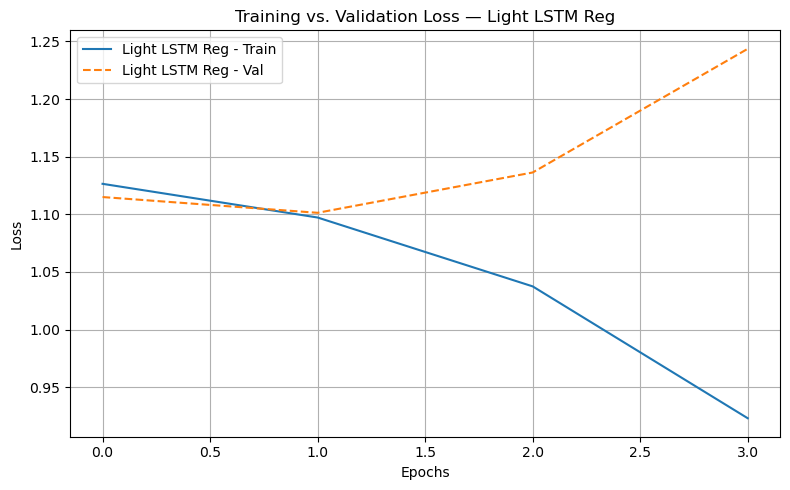

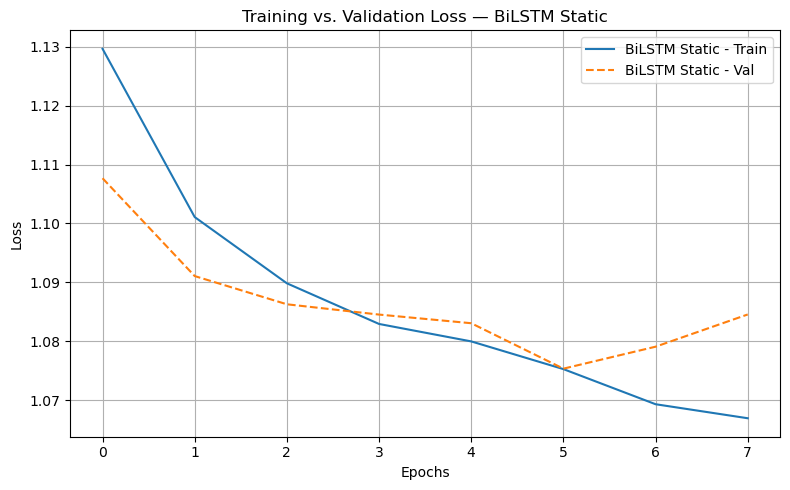

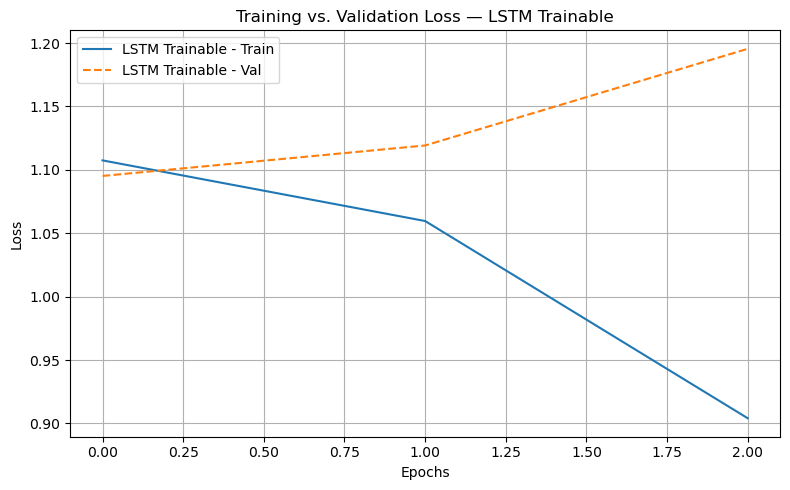

In [77]:
import matplotlib.pyplot as plt

def plot_individual_loss(history, label):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['loss'], label=f'{label} - Train')
    plt.plot(history.history['val_loss'], linestyle='--', label=f'{label} - Val')
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title(f"Training vs. Validation Loss — {label}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Plot each individually
plot_individual_loss(history1, "Light LSTM Reg")
plot_individual_loss(history2, "BiLSTM Static")
plot_individual_loss(history3, "LSTM Trainable")


In [79]:
# Swap embeddings or hyperparameters manually
model4 = model_bilstm_trainable(embedding_layer=embedding_word2vec_trainable, dropout=0.6, lstm_units=32, dense_units=64, l2_reg=0.001)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping



history4 = model4.fit(X_train, y_train,epochs=10, batch_size=64,validation_split=0.1,callbacks=[early_stop],verbose=1)
history5 = model4.fit(X_train, y_train,epochs=10, batch_size=128,validation_split=0.1,callbacks=[early_stop],verbose=1)

Epoch 1/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 82s 287ms/step - accuracy: 0.3851 - loss: 1.1386 - val_accuracy: 0.3998 - val_loss: 1.1207
Epoch 2/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 68s 266ms/step - accuracy: 0.4914 - loss: 1.0394 - val_accuracy: 0.3811 - val_loss: 1.1410
Epoch 3/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 69s 268ms/step - accuracy: 0.5571 - loss: 0.9581 - val_accuracy: 0.3794 - val_loss: 1.2014
Epoch 1/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 55s 427ms/step - accuracy: 0.4958 - loss: 1.0380 - val_accuracy: 0.3899 - val_loss: 1.1568
Epoch 2/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 55s 430ms/step - accuracy: 0.5359 - loss: 0.9828 - val_accuracy: 0.3882 - val_loss: 1.1604
Epoch 3/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 55s 428ms/step - accuracy: 0.5746 - loss: 0.9288 - val_accuracy: 0.3849 - val_loss: 1.1921


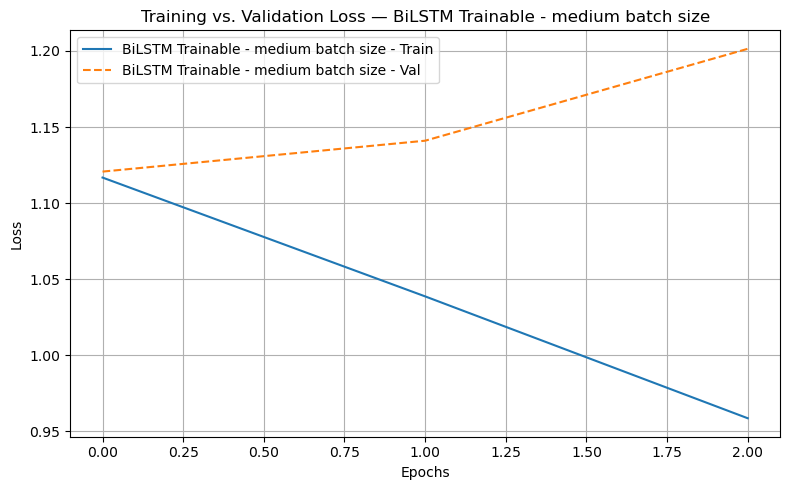

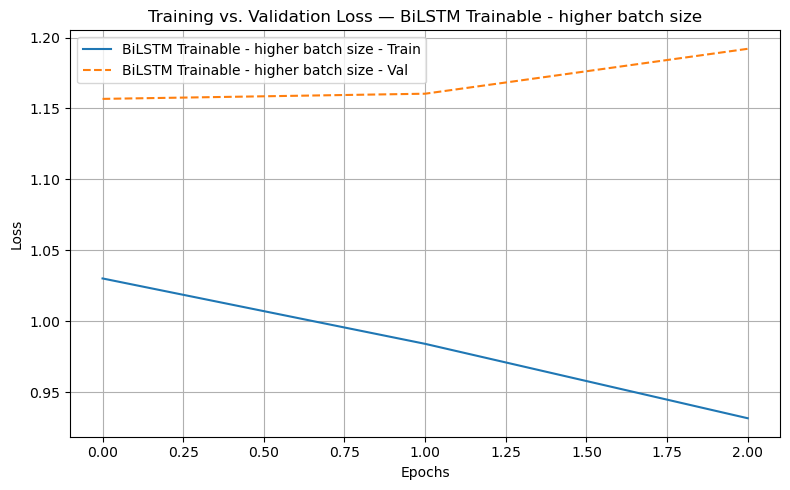

In [81]:
# Plot each individually
plot_individual_loss(history4, "BiLSTM Trainable - medium batch size")
plot_individual_loss(history5, "BiLSTM Trainable - higher batch size")


In [87]:
model6 = model_bilstm_trainable(embedding_layer=embedding_glove_static, lstm_units=32)
model7 = model_bilstm_trainable(embedding_layer=embedding_glove_trainable, lstm_units=32)


In [88]:
history6 = model4.fit(X_train, y_train,epochs=10, batch_size=64,validation_split=0.1,callbacks=[early_stop],verbose=1)
history7 = model4.fit(X_train, y_train,epochs=10, batch_size=64,validation_split=0.1,callbacks=[early_stop],verbose=1)

Epoch 1/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 107s 417ms/step - accuracy: 0.5346 - loss: 0.9883 - val_accuracy: 0.3860 - val_loss: 1.1601
Epoch 2/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 107s 416ms/step - accuracy: 0.5831 - loss: 0.9119 - val_accuracy: 0.3789 - val_loss: 1.2377
Epoch 3/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 109s 427ms/step - accuracy: 0.6506 - loss: 0.8064 - val_accuracy: 0.3756 - val_loss: 1.2937
Epoch 1/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 110s 428ms/step - accuracy: 0.5929 - loss: 0.9018 - val_accuracy: 0.3833 - val_loss: 1.2103
Epoch 2/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 108s 423ms/step - accuracy: 0.6466 - loss: 0.8128 - val_accuracy: 0.3888 - val_loss: 1.3057
Epoch 3/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 108s 423ms/step - accuracy: 0.6937 - loss: 0.7275 - val_accuracy: 0.3733 - val_loss: 1.4177


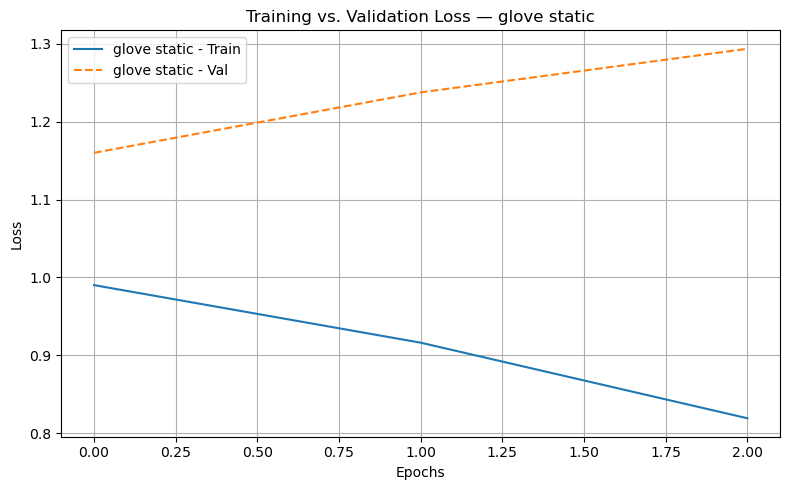

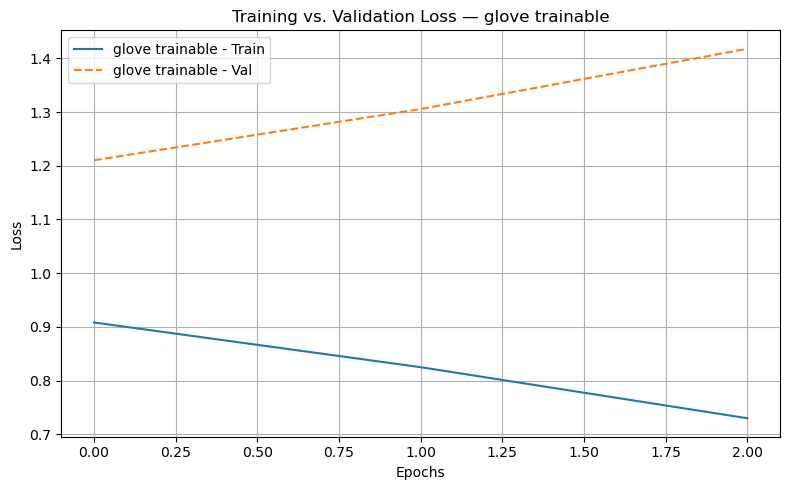

In [89]:
# Plot each individually
plot_individual_loss(history6, "glove static")
plot_individual_loss(history7, "glove trainable")


- new pretrained embedding with reduced dimension (100 instead of 300)

In [91]:
model8 = model_bilstm_trainable(
    embedding_layer=embedding_glove_trainable,
    dropout=0.6,
    lstm_units=16,
    dense_units=32,
    l2_reg=0.01
)

history8 = model8.fit(
    X_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 46s 338ms/step - accuracy: 0.3450 - loss: 1.3585 - val_accuracy: 0.3701 - val_loss: 1.2091
Epoch 2/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 38s 329ms/step - accuracy: 0.3668 - loss: 1.1860 - val_accuracy: 0.3663 - val_loss: 1.1310
Epoch 3/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 38s 329ms/step - accuracy: 0.3676 - loss: 1.1244 - val_accuracy: 0.3690 - val_loss: 1.1033
Epoch 4/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 38s 337ms/step - accuracy: 0.3647 - loss: 1.1052 - val_accuracy: 0.3668 - val_loss: 1.0943
Epoch 5/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 38s 336ms/step - accuracy: 0.3718 - loss: 1.0957 - val_accuracy: 0.3671 - val_loss: 1.0912
Epoch 6/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 40s 350ms/step - accuracy: 0.3745 - loss: 1.0941 - val_accuracy: 0.3712 - val_loss: 1.0900
Epoch 7/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 39s 338ms/step - accuracy: 0.3821 - loss: 1.0908 - val_accuracy: 0.3839 - val_loss: 1.0879
Epoch 8/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 38s 334ms/step - accuracy: 0.3855 - loss: 1

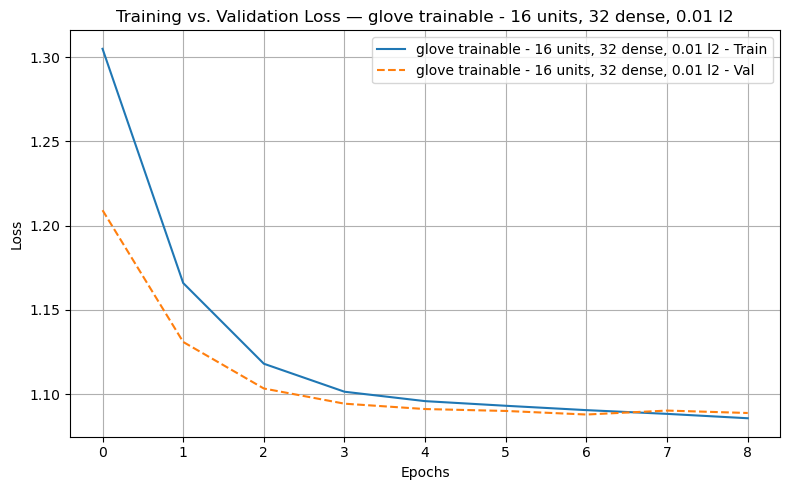

In [92]:
# plot the training history
plot_individual_loss(history8, "glove trainable - 16 units, 32 dense, 0.01 l2")

In [95]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM, Dense, Bidirectional, GaussianNoise, BatchNormalization, Dropout
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

def model_bilstm_trainable_optimized(
    embedding_layer,
    lstm_units=32,
    dense_units=64,
    dropout=0.5,
    l2_reg=0.001,
    learning_rate=0.001
):
    model = Sequential()
    model.add(embedding_layer)
    model.add(GaussianNoise(0.1))
    model.add(BatchNormalization())
    
    # BiLSTM with separate dropout and recurrent dropout
    model.add(Bidirectional(
        LSTM(lstm_units, dropout=dropout, recurrent_dropout=0.2)
    ))

    if dense_units > 0:
        model.add(Dense(
            dense_units,
            activation='selu',
            kernel_regularizer=l2(l2_reg) if l2_reg else None
        ))

    # Output layer for 3-class classification
    model.add(Dense(3, activation='softmax'))

    # Adam optimizer with custom learning rate
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    return model


- addem custom learning rate
- added Gaussian noise layer to reduce overfitting
- increased batch size to reduce overfitting
- increased validation split

In [96]:
model9 = model_bilstm_trainable_optimized(
    embedding_layer=embedding_glove_trainable,
    dropout=0.6,
    lstm_units=32,
    dense_units=32,
    l2_reg=0.01
)

history9 = model9.fit(
    X_train, y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 50s 366ms/step - accuracy: 0.3429 - loss: 1.5008 - val_accuracy: 0.3635 - val_loss: 1.2949
Epoch 2/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 41s 357ms/step - accuracy: 0.3537 - loss: 1.2690 - val_accuracy: 0.3660 - val_loss: 1.1923
Epoch 3/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 41s 363ms/step - accuracy: 0.3743 - loss: 1.1760 - val_accuracy: 0.3674 - val_loss: 1.1457
Epoch 4/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 41s 360ms/step - accuracy: 0.3892 - loss: 1.1313 - val_accuracy: 0.3715 - val_loss: 1.1191
Epoch 5/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 42s 372ms/step - accuracy: 0.4027 - loss: 1.1072 - val_accuracy: 0.3699 - val_loss: 1.1113
Epoch 6/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 43s 378ms/step - accuracy: 0.4011 - loss: 1.0951 - val_accuracy: 0.3823 - val_loss: 1.1057
Epoch 7/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 42s 366ms/step - accuracy: 0.4237 - loss: 1.0822 - val_accuracy: 0.3768 - val_loss: 1.1042
Epoch 8/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 42s 369ms/step - accuracy: 0.4302 - loss: 1

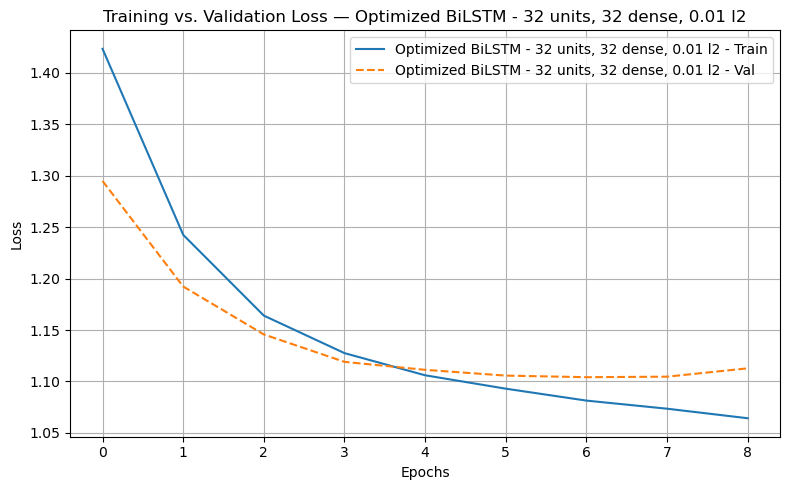

In [97]:
#plot
plot_individual_loss(history9, "Optimized BiLSTM - 32 units, 32 dense, 0.01 l2")

- increase patience for early stopping
- since overfitting in control: more lstm units, reduced dropout, smaller l2

In [100]:
model10 = model_bilstm_trainable_optimized(
    embedding_layer=embedding_glove_trainable,
    dropout=0.5,
    lstm_units=64,
    dense_units=32,
    l2_reg=0.005
)

history10 = model10.fit(
    X_train, y_train,
    epochs=30,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 66s 509ms/step - accuracy: 0.3711 - loss: 1.3584 - val_accuracy: 0.3602 - val_loss: 1.2575
Epoch 2/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 54s 471ms/step - accuracy: 0.4167 - loss: 1.2067 - val_accuracy: 0.3657 - val_loss: 1.1991
Epoch 3/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 54s 476ms/step - accuracy: 0.4449 - loss: 1.1342 - val_accuracy: 0.3586 - val_loss: 1.1758
Epoch 4/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 54s 473ms/step - accuracy: 0.4636 - loss: 1.0893 - val_accuracy: 0.3690 - val_loss: 1.1793
Epoch 5/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 52s 455ms/step - accuracy: 0.4955 - loss: 1.0406 - val_accuracy: 0.3655 - val_loss: 1.1976


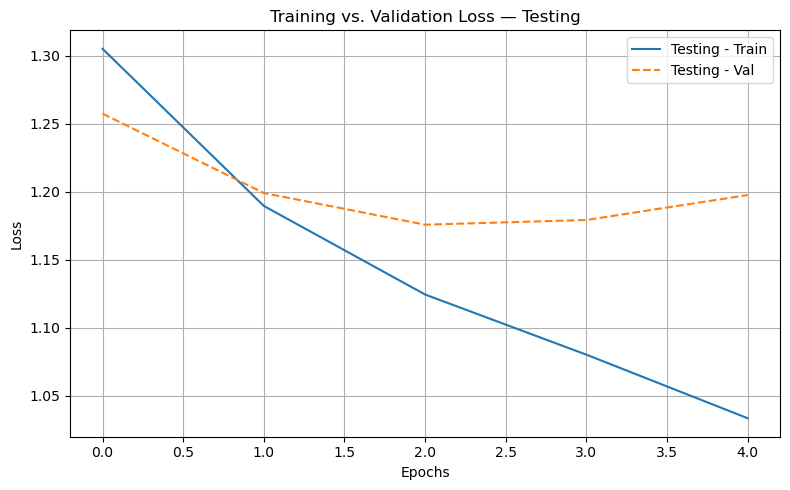

In [102]:
#plot
plot_individual_loss(history10, "Testing")

In [110]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

In [104]:
model11 = model_bilstm_trainable_optimized(
    embedding_layer=embedding_glove_trainable,
    dropout=0.6,
    lstm_units=32,
    dense_units=32,
    l2_reg=0.01
)

history11 = model11.fit(
    X_train, y_train,
    epochs=30,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 45s 318ms/step - accuracy: 0.3440 - loss: 1.4927 - val_accuracy: 0.3671 - val_loss: 1.2938
Epoch 2/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 35s 309ms/step - accuracy: 0.3962 - loss: 1.2428 - val_accuracy: 0.3655 - val_loss: 1.1890
Epoch 3/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 35s 306ms/step - accuracy: 0.4273 - loss: 1.1424 - val_accuracy: 0.3663 - val_loss: 1.1541
Epoch 4/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 35s 305ms/step - accuracy: 0.4477 - loss: 1.0939 - val_accuracy: 0.3660 - val_loss: 1.1640
Epoch 5/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 35s 311ms/step - accuracy: 0.4645 - loss: 1.0614 - val_accuracy: 0.3591 - val_loss: 1.1640
Epoch 6/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 35s 309ms/step - accuracy: 0.4931 - loss: 1.0301 - val_accuracy: 0.3589 - val_loss: 1.1831
Epoch 7/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 35s 304ms/step - accuracy: 0.4990 - loss: 1.0091 - val_accuracy: 0.3646 - val_loss: 1.1832


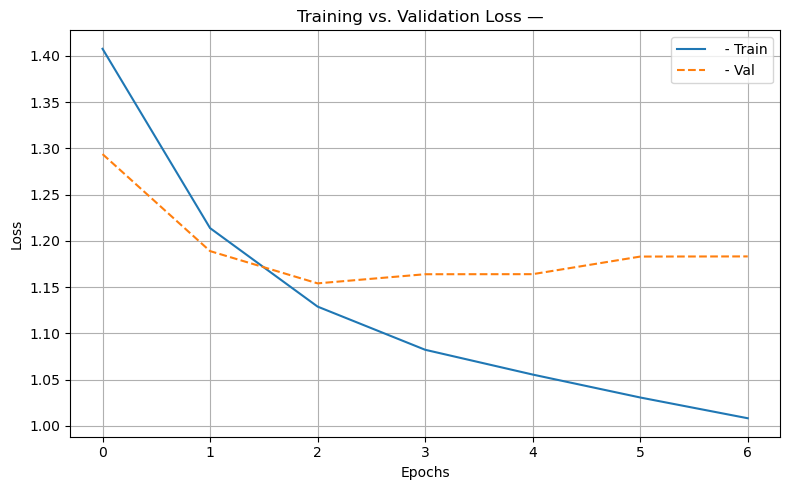

In [105]:
#plot
plot_individual_loss(history11, " ")

In [106]:
model12 = model_bilstm_trainable_optimized(
    embedding_layer=embedding_glove_trainable,
    dropout=0.7,
    lstm_units=32,
    dense_units=32,
    l2_reg=0.015
)

history12 = model12.fit(
    X_train, y_train,
    epochs=30,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 42s 307ms/step - accuracy: 0.3580 - loss: 1.6538 - val_accuracy: 0.3616 - val_loss: 1.3547
Epoch 2/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 30s 266ms/step - accuracy: 0.3813 - loss: 1.2952 - val_accuracy: 0.3712 - val_loss: 1.1922
Epoch 3/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 30s 261ms/step - accuracy: 0.4108 - loss: 1.1590 - val_accuracy: 0.3688 - val_loss: 1.1418
Epoch 4/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 31s 270ms/step - accuracy: 0.4030 - loss: 1.1093 - val_accuracy: 0.3726 - val_loss: 1.1280
Epoch 5/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 30s 260ms/step - accuracy: 0.4317 - loss: 1.0786 - val_accuracy: 0.3718 - val_loss: 1.1292
Epoch 6/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 30s 267ms/step - accuracy: 0.4516 - loss: 1.0616 - val_accuracy: 0.3732 - val_loss: 1.1258
Epoch 7/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 30s 264ms/step - accuracy: 0.4628 - loss: 1.0447 - val_accuracy: 0.3638 - val_loss: 1.1414
Epoch 8/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 31s 267ms/step - accuracy: 0.4761 - loss: 1

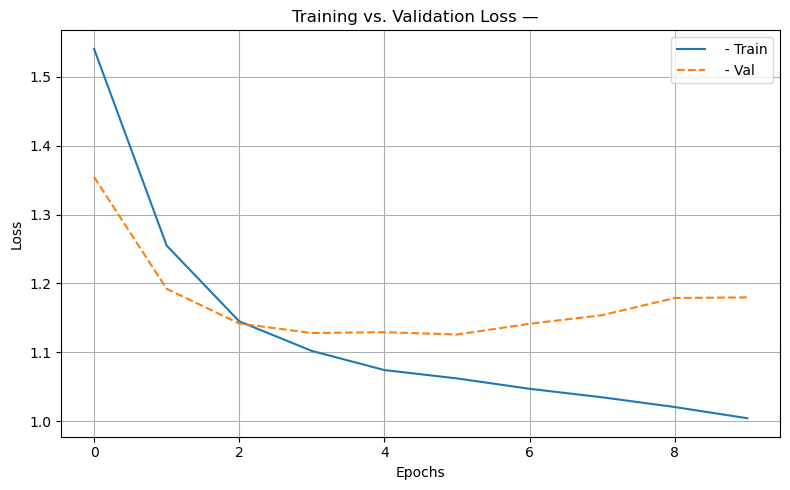

In [107]:
#plot
plot_individual_loss(history12, " ")

In [108]:
model13 = model_bilstm_trainable_optimized(
    embedding_layer=embedding_glove_trainable,
    dropout=0.75,
    lstm_units=16,
    dense_units=32,
    l2_reg=0.015
)

history13 = model13.fit(
    X_train, y_train,
    epochs=30,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 38s 261ms/step - accuracy: 0.3416 - loss: 1.5671 - val_accuracy: 0.3600 - val_loss: 1.3249
Epoch 2/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 31s 268ms/step - accuracy: 0.3659 - loss: 1.2861 - val_accuracy: 0.3522 - val_loss: 1.1976
Epoch 3/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 30s 267ms/step - accuracy: 0.3779 - loss: 1.1750 - val_accuracy: 0.3476 - val_loss: 1.1424
Epoch 4/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 31s 269ms/step - accuracy: 0.3910 - loss: 1.1226 - val_accuracy: 0.3539 - val_loss: 1.1268
Epoch 5/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 31s 270ms/step - accuracy: 0.4061 - loss: 1.0951 - val_accuracy: 0.3564 - val_loss: 1.1156
Epoch 6/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 31s 268ms/step - accuracy: 0.4150 - loss: 1.0822 - val_accuracy: 0.3564 - val_loss: 1.1204
Epoch 7/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 31s 269ms/step - accuracy: 0.4332 - loss: 1.0691 - val_accuracy: 0.3528 - val_loss: 1.1293
Epoch 8/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 32s 282ms/step - accuracy: 0.4398 - loss: 1

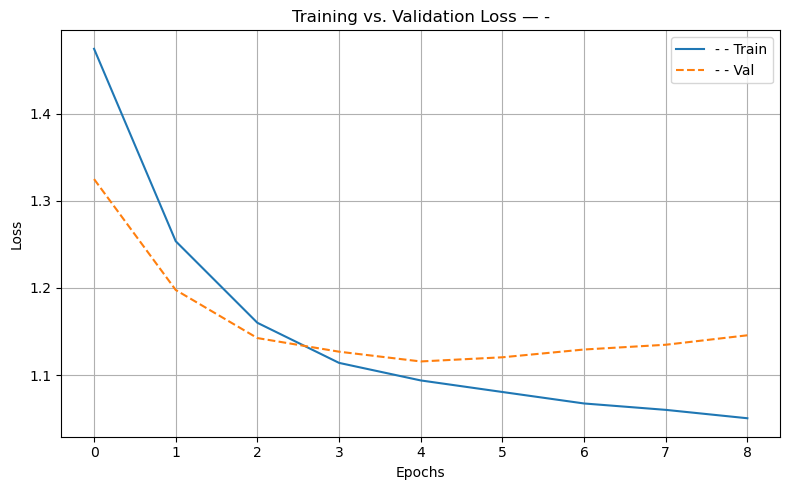

In [109]:
#plot
plot_individual_loss(history13, "-")

In [111]:
model14 = model_bilstm_trainable_optimized(
    embedding_layer=embedding_glove_trainable,
    dropout=0.6,
    lstm_units=24,
    dense_units=32,
    l2_reg=0.015
)

history14 = model14.fit(
    X_train, y_train,
    epochs=30,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 39s 283ms/step - accuracy: 0.3491 - loss: 1.6384 - val_accuracy: 0.3536 - val_loss: 1.3466
Epoch 2/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 30s 266ms/step - accuracy: 0.4081 - loss: 1.2827 - val_accuracy: 0.3608 - val_loss: 1.2152
Epoch 3/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 30s 267ms/step - accuracy: 0.4467 - loss: 1.1425 - val_accuracy: 0.3517 - val_loss: 1.1855
Epoch 4/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 30s 265ms/step - accuracy: 0.4705 - loss: 1.0687 - val_accuracy: 0.3495 - val_loss: 1.1705
Epoch 5/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 30s 265ms/step - accuracy: 0.4980 - loss: 1.0306 - val_accuracy: 0.3517 - val_loss: 1.1786
Epoch 6/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 30s 261ms/step - accuracy: 0.5166 - loss: 1.0003 - val_accuracy: 0.3470 - val_loss: 1.2032
Epoch 7/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 30s 260ms/step - accuracy: 0.5302 - loss: 0.9839 - val_accuracy: 0.3484 - val_loss: 1.2250


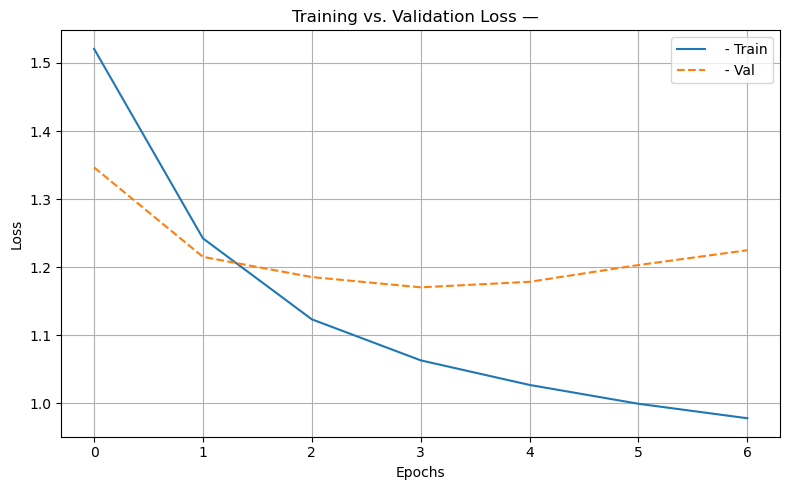

In [112]:
# plot
plot_individual_loss(history14, " ")

### test

In [113]:
# Predict probabilities
y_pred = model13.predict(X_test)

# Convert probabilities to class labels
y_pred_classes = np.argmax(y_pred, axis=1)

# Evaluate
from sklearn.metrics import classification_report

# Print report
print(classification_report(y_test, y_pred_classes, target_names=label_encoder.classes_))

from sklearn.metrics import accuracy_score
print("Test Accuracy:", accuracy_score(y_test, y_pred_classes))


142/142 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step
              precision    recall  f1-score   support

      center       0.37      0.55      0.44      1513
        left       0.38      0.22      0.28      1513
       right       0.38      0.35      0.36      1513

    accuracy                           0.37      4539
   macro avg       0.38      0.37      0.36      4539
weighted avg       0.38      0.37      0.36      4539

Test Accuracy: 0.3729896452963208


### Binary classification

In [187]:
from itertools import product
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
import pandas as pd

# === Binary Classification Model ===
def build_model_lstm_binary(embedding_layer, lstm_units=32, dropout=0.3, dense_units=64, l2_reg=None):
    model = Sequential()
    model.add(embedding_layer)
    model.add(LSTM(lstm_units, dropout=dropout, recurrent_dropout=dropout))
    if dense_units > 0:
        if l2_reg:
            model.add(Dense(dense_units, activation='relu', kernel_regularizer=l2(l2_reg)))
        else:
            model.add(Dense(dense_units, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))  # Binary output
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# === Grid Search for Binary Classification ===
def run_grid_search_lstm_binary(embeddings_dict, X_train, y_train, epochs=10):
    lstm_units_list = [16, 32]
    dropout_list = [0.5]
    dense_units_list = [0, 64]
    l2_list = [None, 0.001]

    param_grid = list(product(
        embeddings_dict.items(),
        lstm_units_list,
        dropout_list,
        dense_units_list,
        l2_list
    ))

    results = []
    early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

    for (emb_name, emb_layer), lstm_units, dropout, dense_units, l2_reg in param_grid:
        model_name = f"{emb_name}_LSTM{lstm_units}_D{dense_units}_drop{int(dropout*10)}_l2{l2_reg or 0}"
        print(f"\n🔧 Training: {model_name}")

        model = build_model_lstm_binary(
            embedding_layer=emb_layer,
            lstm_units=lstm_units,
            dropout=dropout,
            dense_units=dense_units,
            l2_reg=l2_reg
        )

        history = model.fit(
            X_train, y_train,
            epochs=epochs,
            batch_size=64,
            validation_split=0.1,
            callbacks=[early_stop],
            verbose=0
        )

        results.append({
            "model": model_name,
            "embedding": emb_name,
            "lstm_units": lstm_units,
            "dropout": dropout,
            "dense_units": dense_units,
            "l2_reg": l2_reg,
            "val_accuracy": history.history['val_accuracy'][-1],
            "val_loss": history.history['val_loss'][-1]
        })

    return pd.DataFrame(results).sort_values(by="val_accuracy", ascending=False)


In [188]:
results_df_lstm_binary = run_grid_search_lstm_binary(embeddings, X_train_b, y_train_b, epochs=10)


🔧 Training: baseline_LSTM16_D0_drop5_l20

🔧 Training: baseline_LSTM16_D0_drop5_l20.001

🔧 Training: baseline_LSTM16_D64_drop5_l20

🔧 Training: baseline_LSTM16_D64_drop5_l20.001

🔧 Training: baseline_LSTM32_D0_drop5_l20

🔧 Training: baseline_LSTM32_D0_drop5_l20.001

🔧 Training: baseline_LSTM32_D64_drop5_l20

🔧 Training: baseline_LSTM32_D64_drop5_l20.001

🔧 Training: word2vec_static_LSTM16_D0_drop5_l20

🔧 Training: word2vec_static_LSTM16_D0_drop5_l20.001

🔧 Training: word2vec_static_LSTM16_D64_drop5_l20

🔧 Training: word2vec_static_LSTM16_D64_drop5_l20.001

🔧 Training: word2vec_static_LSTM32_D0_drop5_l20

🔧 Training: word2vec_static_LSTM32_D0_drop5_l20.001

🔧 Training: word2vec_static_LSTM32_D64_drop5_l20

🔧 Training: word2vec_static_LSTM32_D64_drop5_l20.001

🔧 Training: word2vec_trainable_LSTM16_D0_drop5_l20

🔧 Training: word2vec_trainable_LSTM16_D0_drop5_l20.001

🔧 Training: word2vec_trainable_LSTM16_D64_drop5_l20

🔧 Training: word2vec_trainable_LSTM16_D64_drop5_l20.001

🔧 Training: w

In [189]:
from itertools import product
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Bidirectional
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
import pandas as pd

# === Binary Classification BiLSTM Model ===
def build_model_bilstm_binary(embedding_layer, lstm_units=32, dropout=0.3, dense_units=64, l2_reg=None):
    model = Sequential()
    model.add(embedding_layer)
    model.add(Bidirectional(LSTM(lstm_units, dropout=dropout, recurrent_dropout=dropout)))  # BiLSTM
    if dense_units > 0:
        if l2_reg:
            model.add(Dense(dense_units, activation='relu', kernel_regularizer=l2(l2_reg)))
        else:
            model.add(Dense(dense_units, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))  # Binary classification output
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# === Grid Search for Binary Classification with BiLSTM ===
def run_grid_search_bilstm_binary(embeddings_dict, X_train, y_train, epochs=10):
    lstm_units_list = [16, 32]
    dropout_list = [0.5]
    dense_units_list = [0, 64]
    l2_list = [None, 0.001]

    param_grid = list(product(
        embeddings_dict.items(),
        lstm_units_list,
        dropout_list,
        dense_units_list,
        l2_list
    ))

    results = []
    early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

    for (emb_name, emb_layer), lstm_units, dropout, dense_units, l2_reg in param_grid:
        model_name = f"{emb_name}_BiLSTM{lstm_units}_D{dense_units}_drop{int(dropout*10)}_l2{l2_reg or 0}"
        print(f"\n🔧 Training: {model_name}")

        model = build_model_bilstm_binary(
            embedding_layer=emb_layer,
            lstm_units=lstm_units,
            dropout=dropout,
            dense_units=dense_units,
            l2_reg=l2_reg
        )

        history = model.fit(
            X_train, y_train,
            epochs=epochs,
            batch_size=64,
            validation_split=0.1,
            callbacks=[early_stop],
            verbose=0
        )

        results.append({
            "model": model_name,
            "embedding": emb_name,
            "lstm_units": lstm_units,
            "dropout": dropout,
            "dense_units": dense_units,
            "l2_reg": l2_reg,
            "val_accuracy": history.history['val_accuracy'][-1],
            "val_loss": history.history['val_loss'][-1]
        })

    return pd.DataFrame(results).sort_values(by="val_accuracy", ascending=False)


In [190]:
results_df_bilstm_binary = run_grid_search_bilstm_binary(embeddings, X_train_b, y_train_b, epochs=10)


🔧 Training: baseline_BiLSTM16_D0_drop5_l20

🔧 Training: baseline_BiLSTM16_D0_drop5_l20.001

🔧 Training: baseline_BiLSTM16_D64_drop5_l20

🔧 Training: baseline_BiLSTM16_D64_drop5_l20.001

🔧 Training: baseline_BiLSTM32_D0_drop5_l20

🔧 Training: baseline_BiLSTM32_D0_drop5_l20.001

🔧 Training: baseline_BiLSTM32_D64_drop5_l20

🔧 Training: baseline_BiLSTM32_D64_drop5_l20.001

🔧 Training: word2vec_static_BiLSTM16_D0_drop5_l20

🔧 Training: word2vec_static_BiLSTM16_D0_drop5_l20.001

🔧 Training: word2vec_static_BiLSTM16_D64_drop5_l20

🔧 Training: word2vec_static_BiLSTM16_D64_drop5_l20.001

🔧 Training: word2vec_static_BiLSTM32_D0_drop5_l20

🔧 Training: word2vec_static_BiLSTM32_D0_drop5_l20.001

🔧 Training: word2vec_static_BiLSTM32_D64_drop5_l20

🔧 Training: word2vec_static_BiLSTM32_D64_drop5_l20.001

🔧 Training: word2vec_trainable_BiLSTM16_D0_drop5_l20

🔧 Training: word2vec_trainable_BiLSTM16_D0_drop5_l20.001

🔧 Training: word2vec_trainable_BiLSTM16_D64_drop5_l20

🔧 Training: word2vec_trainable_B

In [191]:
results_df_lstm_binary

,model,embedding,lstm_units,dropout,dense_units,l2_reg,val_accuracy,val_loss
18,word2vec_trainable_LSTM16_D64_drop5_l20,word2vec_trainable,16,0.5,64,NaN,0.516102,0.780781
3,baseline_LSTM16_D64_drop5_l20.001,baseline,16,0.5,64,0.001,0.515277,0.872486
20,word2vec_trainable_LSTM32_D0_drop5_l20,word2vec_trainable,32,0.5,0,NaN,0.511974,0.829036
12,word2vec_static_LSTM32_D0_drop5_l20,word2vec_static,32,0.5,0,NaN,0.511148,0.693870
17,word2vec_trainable_LSTM16_D0_drop5_l20.001,word2vec_trainable,16,0.5,0,0.001,0.508671,0.747992
16,word2vec_trainable_LSTM16_D0_drop5_l20,word2vec_trainable,16,0.5,0,NaN,0.508671,0.728198
2,baseline_LSTM16_D64_drop5_l20,baseline,16,0.5,64,NaN,0.505367,0.865156
8,word2vec_static_LSTM16_D0_drop5_l20,word2vec_static,16,0.5,0,NaN,0.505367,0.695061
13,word2vec_static_LSTM32_D0_drop5_l20.001,word2vec_static,32,0.5,0,0.001,0.504542,0.694639
5,baseline_LSTM32_D0_drop5_l20.001,baseline,32,0.5,0,0.001,0.504542,0.935653


In [192]:
results_df_bilstm_binary

,model,embedding,lstm_units,dropout,dense_units,l2_reg,val_accuracy,val_loss
10,word2vec_static_BiLSTM16_D64_drop5_l20,word2vec_static,16,0.5,64,NaN,0.524360,0.691535
13,word2vec_static_BiLSTM32_D0_drop5_l20.001,word2vec_static,32,0.5,0,0.001,0.520231,0.693634
8,word2vec_static_BiLSTM16_D0_drop5_l20,word2vec_static,16,0.5,0,NaN,0.516102,0.692717
18,word2vec_trainable_BiLSTM16_D64_drop5_l20,word2vec_trainable,16,0.5,64,NaN,0.511974,0.958450
14,word2vec_static_BiLSTM32_D64_drop5_l20,word2vec_static,32,0.5,64,NaN,0.510322,0.693194
4,baseline_BiLSTM32_D0_drop5_l20,baseline,32,0.5,0,NaN,0.505367,1.081035
16,word2vec_trainable_BiLSTM16_D0_drop5_l20,word2vec_trainable,16,0.5,0,NaN,0.503716,0.926067
7,baseline_BiLSTM32_D64_drop5_l20.001,baseline,32,0.5,64,0.001,0.499587,1.356074
22,word2vec_trainable_BiLSTM32_D64_drop5_l20,word2vec_trainable,32,0.5,64,NaN,0.498761,1.056456
1,baseline_BiLSTM16_D0_drop5_l20.001,baseline,16,0.5,0,0.001,0.497936,1.027540
